<a href="https://colab.research.google.com/github/tmedeirosb/tsi-am/blob/main/MODULO_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Módulo 04 — Classificação com Regressão Logística
### Pipeline organizado + rastreamento de experimentos com W&B

---

## O que você vai conseguir fazer ao fim desta demo

- **Montar** um fluxo de classificação binária com `Pipeline` e `ColumnTransformer` (pré-processamento + modelo num objeto só).
- **Treinar** uma Regressão Logística e **ler os coeficientes** em termos de *odds* (chances).
- **Avaliar** o modelo com matriz de confusão, acurácia, precisão, recall, F1, G-mean e ROC/AUC.
- **Rastrear** o experimento com o Weights & Biases (W&B), salvando **dados, modelo e código** de forma versionada e reprodutível.


## 1. Setup

Instala e importa as bibliotecas. O `wandb` é a ferramenta de rastreamento; o resto a turma já conhece.


In [1]:
# Se estiver no Colab/máquina sem wandb instalado, descomente:
# !pip install wandb scikit-learn pandas matplotlib joblib -q

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Bibliotecas carregadas.")

Bibliotecas carregadas.


## 2. Pasta de saídas (salvar dados, modelo e código)

Criamos uma pasta `artefatos/` onde vamos salvar **tudo que precisa para reproduzir o experimento**: os dados brutos, os splits de treino/teste, o modelo treinado e uma cópia do código. É a mesma ideia de "versionar" que o W&B faz na nuvem — aqui guardamos localmente também.


In [2]:
OUT = "artefatos"
FONTE = "https://raw.githubusercontent.com/tmedeirosb/tsi-ad-2025/refs/heads/main/dados/dados_workflow_ivan.csv"
os.makedirs(OUT, exist_ok=True)

# 1. Carregamento dos dados brutos (recarregando para garantir estado limpo)
df_raw = pd.read_csv(FONTE)

# Salva os dados brutos
df_raw.to_csv(f"{OUT}/raw_data.csv", index=False)
print("Dados brutos salvos em", f"{OUT}/raw_data.csv")

Dados brutos salvos em artefatos/raw_data.csv


## 3. Pipeline de pré-processamento + modelo

Em vez de tratar coluna por coluna na mão, encapsulamos tudo num **`Pipeline`**:

- colunas **numéricas** → preenche faltantes pela média + padroniza a escala (`StandardScaler`);
- colunas **categóricas** → vira colunas 0/1 (`OneHotEncoder`);
- por fim, o **classificador** (`LogisticRegression`).

A vantagem: o mesmo objeto faz pré-processamento **e** previsão. Não há risco de esquecer um passo no teste, e dá para salvar o pipeline inteiro num arquivo só.


In [3]:
# 1. Definição das colunas por tipo de tratamento
num_features = [
    'LnguaPortuguesaeLiteraturaI90H',
    'LnguaPortuguesaeLiteraturaI90H_freq',
    'MatemticaI120H',
    'MatemticaI120H_freq'
]

log_features = ['qnt_salarios']

cat_features = [
    'descricao_area_residencial', 'descricao_companhia_domiciliar',
    'descricao_estado_civil', 'descricao_historico', 'descricao_imovel',
    'descricao_mae_escolaridade', 'descricao_pai_escolaridade', 'descricao_raca',
    'descricao_responsavel_escolaridade', 'descricao_responsavel_financeiro',
    'descricao_trabalho', 'pessoa_fisica__sexo', 'sigla'
]

# 2. Definição dos Pipelines de Transformação
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# CORREÇÃO: Adicionado feature_names_out='one-to-one' para evitar o erro no get_feature_names_out
log_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('log', FunctionTransformer(np.log1p, feature_names_out='one-to-one'))
])

cat_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
])

# 3. Composição do ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('log', log_transformer, log_features),
        ('cat', cat_transformer, cat_features)
    ],
    remainder='drop'
)

# 4. Pipeline Final
clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

# 5. Preparação para Treino
X = df_raw.drop(columns=['classe', 'id'], errors='ignore')
y = df_raw['classe']

# Inverter os valores da classe (0 -> 1, 1 -> 0)
y = 1 - y

print("Classe invertida!")
print(f"Distribuição da classe (invertida):\n{y.value_counts()}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 6. Treinamento
clf_pipeline.fit(X_train, y_train)

# 7. Avaliação
y_pred = clf_pipeline.predict(X_test)

print("Relatório de Classificação:")
print(classification_report(y_test, y_pred))

clf_pipeline

Classe invertida!
Distribuição da classe (invertida):
classe
0    8352
1     556
Name: count, dtype: int64
Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1671
           1       0.68      0.48      0.56       111

    accuracy                           0.95      1782
   macro avg       0.82      0.73      0.77      1782
weighted avg       0.95      0.95      0.95      1782



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['LnguaPortuguesaeLiteraturaI90H',
                                                   'LnguaPortuguesaeLiteraturaI90H_freq',
                                                   'MatemticaI120H',
                                                   'MatemticaI120H_freq']),
                                                 ('log',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('log',
                                                                   FunctionTransform...
                                                   'descricao_companhia_domiciliar',
                                                   'descricao_estado_civil',
                                                   'descricao_historico',
                                                   'descricao_imovel',
                                                   'descricao_mae_escolaridade',
                                                   'descricao_pai_escolaridade',
                                                   'descricao_raca',
                                                   'descricao_responsavel_escolaridade',
                                                   'descricao_responsavel_financeiro',
                                                   'descricao_trabalho',
                                                   'pessoa_fisica__sexo',
                                                   'sigla'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

## 4. Lendo os coeficientes em *odds* (interpretação)

Esta é a parte que conecta com o **Painel de Parâmetros** do Lab. A Regressão Logística aprende um peso para cada feature. O peso (`coef`) está na escala do *logit* (z). Para interpretar em **chances (odds)**, aplicamos `exp(peso)`:

- `exp(peso) > 1` → aquela feature **aumenta** a chance de ser classe 1;
- `exp(peso) < 1` → **diminui** a chance;
- `exp(peso) = 1` → não muda nada.

Exemplo de leitura: um *odds ratio* de **1.8** significa "a cada unidade a mais nessa variável, a **chance** de ser classe 1 fica ~80% maior".


In [4]:
# Recupera os nomes das colunas depois do pré-processamento
nomes = clf_pipeline.named_steps['preprocessor'].get_feature_names_out()
pesos = clf_pipeline.named_steps['classifier'].coef_[0]
intercepto = clf_pipeline.named_steps['classifier'].intercept_[0]

coef_df = pd.DataFrame({
    'feature': nomes,
    'peso (logit)': pesos,
    'odds_ratio = exp(peso)': np.exp(pesos)
}).sort_values('odds_ratio = exp(peso)', ascending=False)

print(f"Intercepto (viés θ0) = {intercepto:.3f}")
coef_df.head(10)

Intercepto (viés θ0) = -2.503


,feature,peso (logit),odds_ratio = exp(peso)
130,cat__sigla_SC,1.170116,3.222367
109,cat__descricao_trabalho_Não informado,0.952852,2.593095
50,cat__descricao_historico_Técnico de Nível Médi...,0.943375,2.568636
126,cat__sigla_NC,0.812519,2.253578
23,cat__descricao_historico_Técnico de Nivel Médi...,0.746879,2.110403
115,cat__sigla_CA,0.708103,2.030137
46,cat__descricao_historico_Técnico de Nível Médi...,0.690525,1.994762
11,cat__descricao_companhia_domiciliar_Outros,0.683421,1.980642
98,cat__descricao_responsavel_financeiro_O própri...,0.641069,1.898509
37,cat__descricao_historico_Técnico de Nível Médi...,0.639735,1.895978


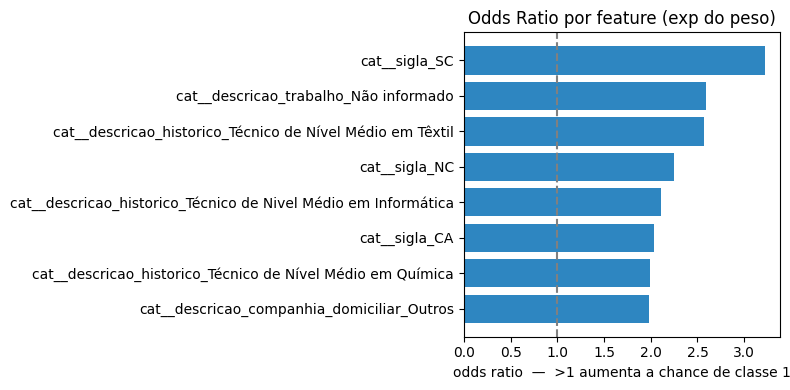

In [5]:
# Visualiza os odds ratios — acima de 1 puxa para classe 1, abaixo puxa para classe 0
top = coef_df.head(8).iloc[::-1]
plt.figure(figsize=(8, 4))
cores = ['#2E86C1' if v >= 1 else '#C0392B' for v in top['odds_ratio = exp(peso)']]
plt.barh(top['feature'], top['odds_ratio = exp(peso)'], color=cores)
plt.axvline(1.0, color='gray', linestyle='--')
plt.title('Odds Ratio por feature (exp do peso)')
plt.xlabel('odds ratio  —  >1 aumenta a chance de classe 1')
plt.tight_layout()
plt.show()

## 5. Avaliação — as métricas da aula

Agora reproduzimos o app *Métricas de Avaliação*. Primeiro a **matriz de confusão** (TP, FP, TN, FN), depois cada métrica.


Matriz de confusão:
 [[1646   25]
 [  58   53]]


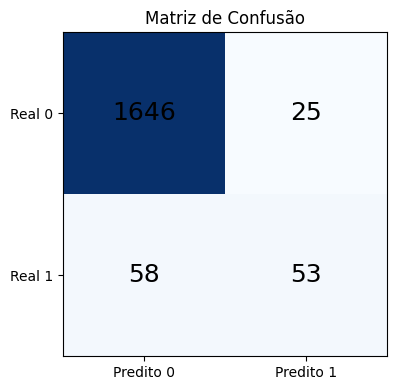

In [6]:
y_pred = clf_pipeline.predict(X_test)
y_proba = clf_pipeline.predict_proba(X_test)[:, 1]   # probabilidade da classe 1 (a sigmoid!)

cm = confusion_matrix(y_test, y_pred)
print("Matriz de confusão:\n", cm)

fig, ax = plt.subplots(figsize=(4.5, 4))
ax.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=18)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Predito 0', 'Predito 1'])
ax.set_yticklabels(['Real 0', 'Real 1'])
ax.set_title('Matriz de Confusão')
plt.tight_layout(); plt.show()

In [7]:
# Métricas (mesmas fórmulas do app)
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)
auc  = roc_auc_score(y_test, y_proba)

# G-mean = raiz(recall_classe1 * recall_classe0) -> robusta a desbalanceamento
rec0 = recall_score(y_test, y_pred, pos_label=0, zero_division=0)
gmean = np.sqrt(rec * rec0)

metricas = {
    "acuracia": acc, "precisao": prec, "recall": rec,
    "f1": f1, "g_mean": gmean, "roc_auc": auc
}
for k, v in metricas.items():
    print(f"{k:>10}: {v:.4f}")

  acuracia: 0.9534
  precisao: 0.6795
    recall: 0.4775
        f1: 0.5608
    g_mean: 0.6858
   roc_auc: 0.8959


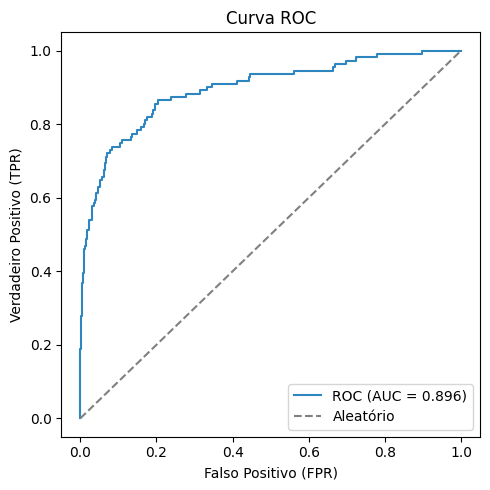

In [8]:
# Curva ROC — o trade-off entre acertar positivos e errar negativos
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, color='#2E86C1', label=f'ROC (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Aleatório')
plt.xlabel('Falso Positivo (FPR)'); plt.ylabel('Verdadeiro Positivo (TPR)')
plt.title('Curva ROC'); plt.legend(); plt.tight_layout(); plt.show()

## 6. Rastreamento com Weights & Biases (W&B)

Até aqui salvamos tudo localmente. O **W&B** leva isso para a nuvem de forma organizada: cada execução vira um *run* com seus **hiperparâmetros**, **métricas** e **artefatos** (dados, modelo, código). Assim você compara experimentos e nunca perde "qual versão deu qual resultado".

Os 3 conceitos que importam:

- **`config`** → os ajustes do experimento (modelo, test_size...).
- **`log`** → as métricas obtidas.
- **`Artifact`** → arquivos versionados: dataset, modelo (`.pkl`), ambiente.

> Para rodar de verdade na nuvem, faça login com sua chave (`wandb.login()`). Aqui usamos **modo offline** para a demo funcionar sem conta — os arquivos ficam salvos em `wandb/` e podem ser enviados depois com `wandb sync`.


In [9]:
import wandb
from google.colab import userdata


# Modo offline: roda sem login/internet e grava tudo localmente.
# Para usar online, comente a linha abaixo e rode wandb.login().
# os.environ["WANDB_MODE"] = "offline"

# 1. Autenticação e Inicialização
try:
    api_key = userdata.get('WANDB_API_KEY')
    os.environ["WANDB_API_KEY"] = api_key
    wandb.login()
except Exception:
    wandb.login()

run = wandb.init(
    project="modulo_04_classificacao",
    name="logreg_pipeline",
    job_type="treino-classificacao",
    save_code=True,                 # salva o CÓDIGO do experimento
    config={
        "modelo": "LogisticRegression",
        "test_size": 0.3,
        "random_state": RANDOM_STATE,
        "fonte_dados": FONTE,
    }
)
print("Run iniciado:", run.name)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: tmedeirosb to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Run iniciado: logreg_pipeline


In [10]:
# (a) Registra as MÉTRICAS
run.log(metricas)

# (b) Versiona os DADOS como artefato
art_dados = wandb.Artifact("dataset", type="dataset",
                           metadata={"linhas": len(df_raw), "fonte": FONTE})
art_dados.add_file(f"{OUT}/raw_data.csv")

run.log_artifact(art_dados)
print("Dados versionados.")

Dados versionados.


In [11]:
# (c) Salva e versiona o MODELO treinado (pipeline inteiro num arquivo só)
model_path = f"{OUT}/modelo_logreg_pipeline.pkl"
joblib.dump(clf_pipeline, model_path)

art_modelo = wandb.Artifact("modelo_logreg", type="model",
                            metadata=metricas)
art_modelo.add_file(model_path)
run.log_artifact(art_modelo)
print("Modelo salvo em", model_path)

Modelo salvo em artefatos/modelo_logreg_pipeline.pkl


In [12]:
# (d) Versiona o AMBIENTE (para reprodutibilidade)
os.system("pip freeze > requirements.txt")
art_env = wandb.Artifact("ambiente", type="environment")
art_env.add_file("requirements.txt")
run.log_artifact(art_env)

run.finish()
print("Run finalizado! Dados, modelo, código e métricas registrados no W&B.")

wandb: WARNING Artifact "dataset" already exists with the same content. No new version will be created.


acuracia,▁
f1,▁
g_mean,▁
precisao,▁
recall,▁
roc_auc,▁
acuracia,0.95342
f1,0.56085
g_mean,0.68581
precisao,0.67949
recall,0.47748


Run finalizado! Dados, modelo, código e métricas registrados no W&B.


## 8. Conferindo o que foi salvo

Tudo que precisamos para reproduzir o experimento está em disco — exatamente o objetivo: **dados + modelo + código versionados.**


In [13]:
print("Conteúdo da pasta de artefatos:")
for f in sorted(os.listdir(OUT)):
    print("  -", f)

# Reabrindo o modelo salvo e usando direto (sem retreinar)
modelo_carregado = joblib.load(model_path)
exemplo = X_test.iloc[[0]]
print("\nExemplo de previsão com o modelo recarregado:")
print("  prob classe 1 =", modelo_carregado.predict_proba(exemplo)[0, 1].round(3))
print("  classe prevista =", modelo_carregado.predict(exemplo)[0])

Conteúdo da pasta de artefatos:
  - modelo_logreg_pipeline.pkl
  - raw_data.csv

Exemplo de previsão com o modelo recarregado:
  prob classe 1 = 0.023
  classe prevista = 0
